# Simple Pendulum Component

## Overview
In this tutorial we implement a minimal `CoSimComponent` and run a single-component simulation.
The goal is to learn the interface: define ports, initialize state, advance one time step, and update outputs.
We also add a torque input to show how external inputs are supplied.


## Learning Goals

- Identify the three required hooks: `_initialize_component`, `_do_step_internal`, and `_update_output_states`
- Define input and output ports and parameters
- Run a single-component simulation and inspect time-series outputs
- Modify parameters and rerun the simulation


## Prerequisites and Setup

- You have installed `syssimx` and its Python dependencies
- You have `numpy` and `matplotlib` available
- You are comfortable running Jupyter Notebook cells
- This tutorial is self-contained and does not require any FMU files


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from syssimx import CoSimComponent
from syssimx.core.port import PortSpec, PortType
from syssimx.utilities import Quantity

## Model Equations

We model a simple pendulum with angle `theta` and angular velocity `omega`. An external torque `tau` is applied at the pivot.

\begin{align*}
\dot{\theta} &= \omega \\
\dot{\omega} &= -\frac{m g L}{I} \sin(\theta) + \frac{\tau}{I}
\end{align*}

where:
- $m$ is the mass of the pendulum
- $g$ is the gravitational acceleration
- $L$ is the length of the pendulum
- $I$ is the moment of inertia about the pivot
- $\tau$ is the external torque input
We integrate these equations with explicit Euler time stepping.


![PendulumFigure](figures/Pendulum_gravity.svg)

**Figure:** A simple pendulum under the influence of gravity. Source: [Wikipedia](https://en.wikipedia.org/wiki/Pendulum_(mechanics)#/media/File:Pendulum_gravity.svg)

## Model Definition

State variables:
- `theta`: angle (rad)
- `omega`: angular velocity (rad/s)

Input:
- `tau`: external torque at the pivot (N*m)

Outputs:
- `theta`, `omega`, and `alpha` (angular acceleration)

Initial conditions are provided by parameters `q0` and `omega0`.


## Implementation as CoSimComponent

We define a `SimplePendulum` component with input and output ports and parameters. The three required hooks are:

- `_initialize_component`: set initial state
- `_do_step_internal`: advance the state by one time step
- `_update_output_states`: publish outputs


### Define the Component Class

**Construction**
- Define parameters and ports.
- Store internal state variables.

**Time stepping**
- Use explicit Euler to advance the state.

**Output updates**
- Write `theta`, `omega`, and `alpha` to the output ports.

**Reset**
- Restore default parameters and clear internal state.


In [2]:
class Pendulum(CoSimComponent):

    def __init__(self, name, label=None, group=None):
        super().__init__(name, label, group)

        self._theta = 0.0
        self._omega = 0.0
        self._alpha = 0.0

        self.input_specs.update({
            "tau": PortSpec(name="tau", type=PortType.REAL, direction="in", unit="N*m"),
        })
        self.output_specs.update({
            "theta": PortSpec(name="theta", type=PortType.REAL, direction="out", unit="rad"),
            "omega": PortSpec(name="omega", type=PortType.REAL, direction="out", unit="rad/s"),
            "alpha": PortSpec(name="alpha", type=PortType.REAL, direction="out", unit="rad/s^2"),
        })

        self._set_default_parameter_values()

    def _set_default_parameter_values(self):
        self.parameters.update({
            "L": Quantity(0.6, "m"),
            "m": Quantity(40, "kg"),
            "inertia": Quantity(20, "kg*m^2"),
            "g": Quantity(9.81, "m/s^2"),
            "q0": Quantity(0.0, "rad"),
            "omega0": Quantity(0.0, "rad/s"),
        })

    def _pendulum_dynamics(self, y: np.ndarray, tau: float):
        theta, omega = y
        m = self.parameters["m"].magnitude
        g = self.parameters["g"].magnitude
        L = self.parameters["L"].magnitude
        I = self.parameters["inertia"].magnitude

        alpha = -(m * g * L * np.sin(theta)) / I + tau / I
        return np.array([omega, alpha])

    def _initialize_component(self, t0):
        self._theta = self.parameters["q0"].magnitude
        self._omega = self.parameters["omega0"].magnitude
        y = np.array([self._theta, self._omega])
        self._alpha = self._pendulum_dynamics(y, tau=0.0)[1]

    def _update_output_states(self, t: float | None = None, event_names: list[str] | None = None):
        self.outputs["theta"].set(self._theta, t)
        self.outputs["omega"].set(self._omega, t)
        self.outputs["alpha"].set(self._alpha, t)

    def _do_step_internal(self, t, dt):
        tau = self.inputs["tau"].get().magnitude
        y = np.array([self._theta, self._omega])
        dydt = self._pendulum_dynamics(y, tau)
        y_next = y + dt * dydt

        self._theta, self._omega = y_next
        self._alpha = self._pendulum_dynamics(y_next, tau)[1]

    def reset(self):
        super().reset()

        self.parameters.clear()
        self._set_default_parameter_values()

        self._theta = 0.0
        self._omega = 0.0
        self._alpha = 0.0


### Create an Instance of the Pendulum Component

In [3]:
pendulum = Pendulum("MyFirstPendulum")

### Modifying Model Parameters

In [4]:
#pendulum.set_parameters(q0=0.3)
original_params = pendulum.get_parameters()
print("Default Parameters:")
for key, value in original_params.items():
    print(f"{key:>10}: {value}")

Default Parameters:
         L: 0.6 m
         m: 40 kg
   inertia: 20 kg·m²
         g: 9.81 m/s²
        q0: 0.0 rad
    omega0: 0.0 rad/s


We can modify the model parameters of the component using the `set_parameters` method.

**Option 1: Set value of a `Quantity` parameter**
- Pass the new magnitude directly as a keyword argument.
- This assumes the default unit defined in the component.

**Option 2: Set value using `Quantity`**
- Create a `Quantity` object with the desired magnitude and unit.

**Option 3: Set parameter using a compatible unit**
- Create a `Quantity` object with a different but compatible unit (e.g., centimeters instead of meters).
- The `set_parameters` method will handle the unit conversion automatically.


In [5]:
# Option 1: Set value of a Quantity parameter, assuming default unit
pendulum.set_parameters(L=0.8)
print('Option 1:', pendulum.get_parameters('L'))

# Option 2: Set value using Quantity
L = Quantity(0.5, 'm')
pendulum.set_parameters(L=L)
print('Option 2:', pendulum.get_parameters('L'))

# Option 3: Set value using Quantity with different unit
L_cm = Quantity(60, 'cm')  # 60 centimeters
pendulum.set_parameters(L=L_cm)
print('Option 3:', pendulum.get_parameters('L'))

# Retrieving error for unit mismatch
try:
    pendulum.set_parameters(L=Quantity(2, 'kg'))  # Unit mismatch
except Exception as e:
    print(f'Error: {e}')

Option 1: {'L': <Quantity(0.8, 'meter')>}
Option 2: {'L': <Quantity(0.5, 'meter')>}
Option 3: {'L': <Quantity(0.6, 'meter')>}
Error: Parameter 'L' expects units compatible with 'm', got 'kg'.


You can retrieve multiple parameters at once by passing an unpacked list of parameter names to `get_parameters(*args)` or set several parameters by passing a dictionary to `set_parameters`.


In [6]:
batch_parameters = pendulum.get_parameters(*['L', 'm', 'g'])
print("Batch Retrieved Parameters:")
for key, value in batch_parameters.items():
    print(f"{key:>10}: {value}")

Batch Retrieved Parameters:
         L: 0.6 m
         m: 40 kg
         g: 9.81 m/s²


In [7]:
new_params = {
    'L': Quantity(1.0, 'm'),
    'm': Quantity(2.0, 'kg'),
    'g': Quantity(9.81, 'm/s^2')
}
pendulum.set_parameters(**new_params)
updated_params = pendulum.get_parameters(*new_params.keys())
print("Batch Updated Parameters:")
for key, value in updated_params.items():
    print(f"{key:>10}: {value}")

pendulum.set_parameters(**original_params)  # Reset to original parameters
print("\nParameters Reset to Original:")
for key, value in pendulum.get_parameters().items():
    print(f"{key:>10}: {value}")

Batch Updated Parameters:
         L: 1.0 m
         m: 2.0 kg
         g: 9.81 m/s²

Parameters Reset to Original:
         L: 0.6 m
         m: 40 kg
   inertia: 20 kg·m²
         g: 9.81 m/s²
        q0: 0.0 rad
    omega0: 0.0 rad/s


### Run the Simulation

We simulate for 5 seconds with a fixed step size of 1 ms. Because this tutorial focuses on the component interface, we drive the component directly with `do_step` in a loop — no `System` is involved yet.

In [8]:
t0 = 0.0
time_end = 5
dt = 1e-3
time_points = np.arange(0.0, time_end, dt)

#### Free Swing
First, we simulate the pendulum without any external torque to observe its free swing.

We define an initial angular position `q0 = 0.3 rad` and zero initial angular velocity `omega0 = 0 rad/s`.

In [9]:
pendulum.reset()
pendulum.set_parameters(q0=0.3)
pendulum.initialize(t0)

for t in time_points:
    pendulum.do_step(t, dt)

**Retrieve history and plot the results**

In [10]:
history = pendulum.get_history()

times = history["theta"]['time']
thetas = history["theta"]['values']
omegas = history["omega"]['values']
alphas = history["alpha"]['values']

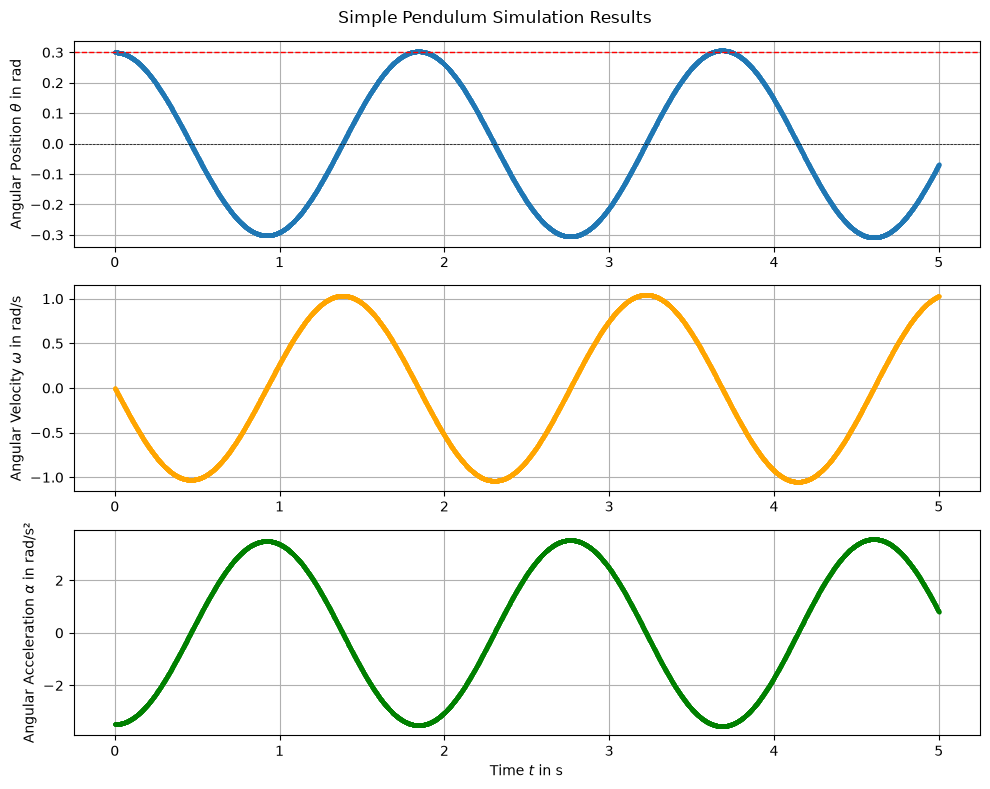

In [11]:
style = {'marker': 'o', 'markersize': 2, 'linestyle': '-'}
plt.figure(figsize=(10, 8))
plt.suptitle("Simple Pendulum Simulation Results")
plt.subplot(3, 1, 1)
plt.plot(times, thetas, **style)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axhline(pendulum.parameters["q0"], color='red', linewidth=1, linestyle='--', label='Initial Angle')
plt.grid()
plt.ylabel(r'Angular Position $\theta$ in rad')

plt.subplot(3, 1, 2)
plt.plot(times, omegas, color='orange', **style)
plt.grid()
plt.ylabel(r'Angular Velocity $\omega$ in rad/s')

plt.subplot(3, 1, 3)
plt.plot(times, alphas, color='green', **style)
plt.grid()
plt.ylabel(r'Angular Acceleration $\alpha$ in rad/s²')
plt.xlabel(r'Time $t$ in s')

plt.tight_layout()
plt.show()

#### With External Torque

A small torque step is applied after 1 second to demonstrate how inputs are provided to a component.

In [12]:
pendulum.reset()
pendulum.initialize(t0)

def torque_input(t):
    return 1 if t >= 1.0 else 0.0

for t in time_points:
    pendulum.set_inputs({"tau": torque_input(t)}, t=t)
    pendulum.do_step(t, dt)

**Retrieve history and plot the results**

In [13]:
history = pendulum.get_history()

times = history["theta"]['time']
thetas = history["theta"]['values']
omegas = history["omega"]['values']
alphas = history["alpha"]['values']

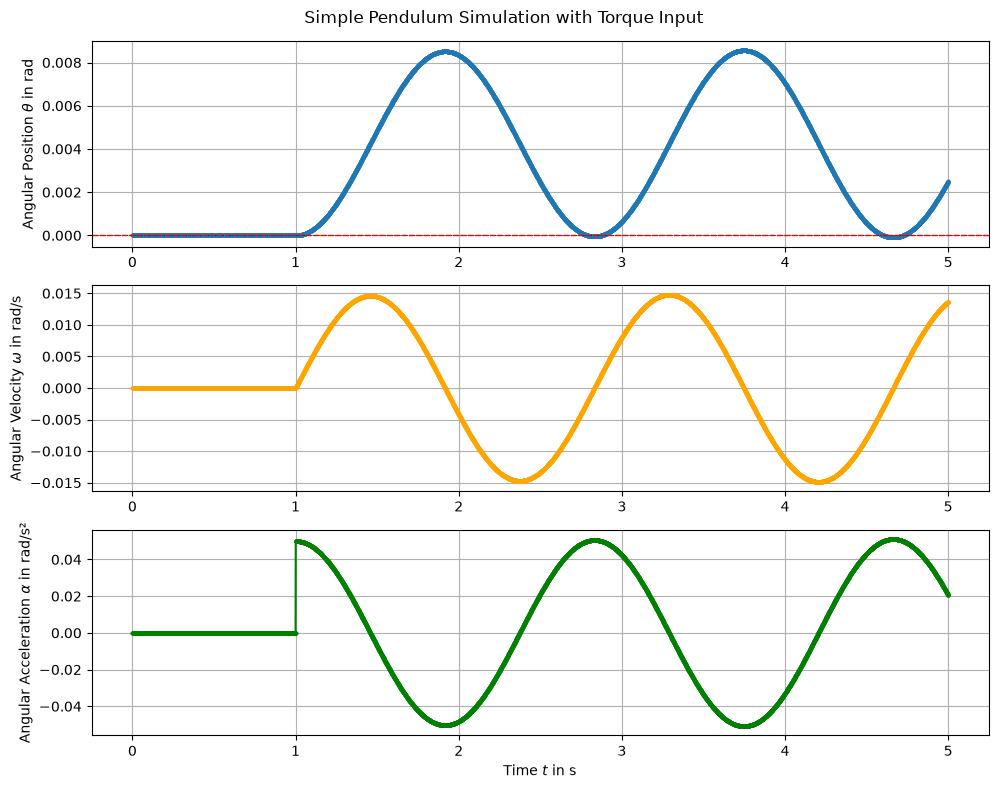

In [14]:
style = {'marker': 'o', 'markersize': 2, 'linestyle': '-'}
plt.figure(figsize=(10, 8))
plt.suptitle("Simple Pendulum Simulation with Torque Input")
plt.subplot(3, 1, 1)
plt.plot(times, thetas, **style)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axhline(pendulum.parameters["q0"], color='red', linewidth=1, linestyle='--', label='Initial Angle')
plt.grid()
plt.ylabel(r'Angular Position $\theta$ in rad')

plt.subplot(3, 1, 2)
plt.plot(times, omegas, color='orange', **style)
plt.grid()
plt.ylabel(r'Angular Velocity $\omega$ in rad/s')

plt.subplot(3, 1, 3)
plt.plot(times, alphas, color='green', **style)
plt.grid()
plt.ylabel(r'Angular Acceleration $\alpha$ in rad/s²')
plt.xlabel(r'Time $t$ in s')

plt.tight_layout()
plt.show()

## Comparing Parameter Configurations


In [15]:
pendulum.reset()
default_config = pendulum.get_parameters()
print("Default Parameters:")
for k, v in default_config.items():
    print(f" - {k}: {v}")

Default Parameters:
 - L: 0.6 m
 - m: 40 kg
 - inertia: 20 kg·m²
 - g: 9.81 m/s²
 - q0: 0.0 rad
 - omega0: 0.0 rad/s


In [16]:
pendulum.reset()
default_config = pendulum.get_parameters()

config1 = {
    'L': 2 * default_config['L'],
    'm': 2 * default_config['m'],
}

config2 = {
    'L': 0.5 * default_config['L'],
    'm': 0.5 * default_config['m']
}

labels = ['Default', 'Config 1 -  $2L, 2m$', 'Config 2 - $L/2, m/2$']
configs = [default_config, config1, config2]
histories = []

In [17]:
for i, config in enumerate(configs):
    pendulum.reset()
    pendulum.set_parameters(**config)

    pendulum.initialize(t0=0.0)
    for t in time_points:
        pendulum.set_inputs({'tau': torque_input(t)}, t=t)
        pendulum.do_step(t, dt)

    histories.append(pendulum.get_history())

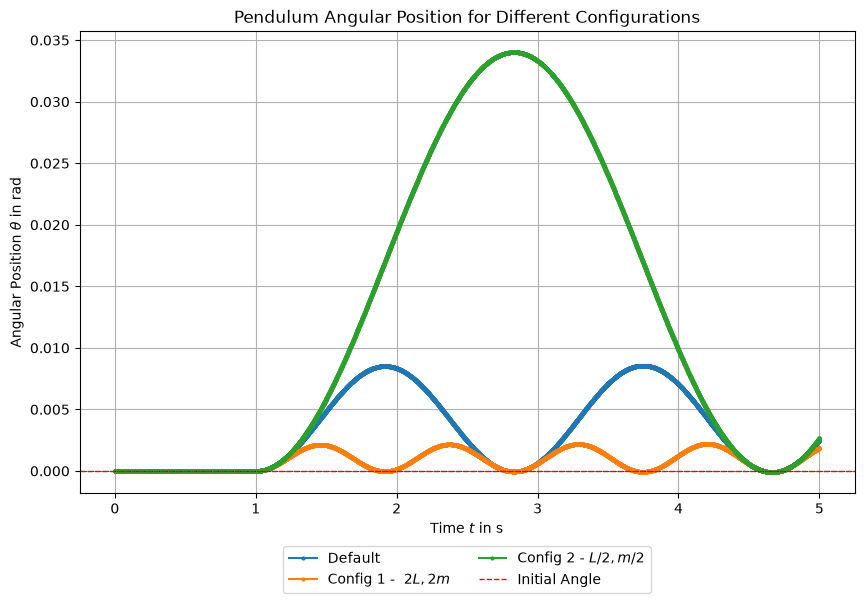

In [18]:
plt.figure(figsize=(10, 6))

for i, history in enumerate(histories):
    times = history["theta"]['time']
    thetas = history["theta"]['values']
    plt.plot(times, thetas, label=labels[i], **style)

plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axhline(pendulum.parameters["q0"], color='red', linewidth=1, linestyle='--', label='Initial Angle')

plt.title('Pendulum Angular Position for Different Configurations')
plt.xlabel(r'Time $t$ in s')
plt.ylabel(r'Angular Position $\theta$ in rad')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.grid()


This comparison shows how changes in length and mass affect the pendulum motion.


## Running the Component in a System

Driving `do_step` by hand is instructive, but in practice components run inside a `System`, which handles initialization, stepping, and history recording. `system.run()` returns a `SimulationResult` with the recorded outputs and run metadata. The unconnected `tau` input defaults to zero, so this reproduces the free swing.

In [19]:
from syssimx import System

free_pendulum = Pendulum("Pendulum")
free_pendulum.set_parameters(q0=0.3)

system = System(name="PendulumSystem")
system.add_component(free_pendulum)
system.initialize(t0=0.0)

result = system.run(t0=0.0, tf=5.0, dt=1e-3)
result

<SimulationResult 'PendulumSystem' t=[0.0, 5.0] dt=0.001 components=1 algorithm=GaussSeidelAlgorithm>

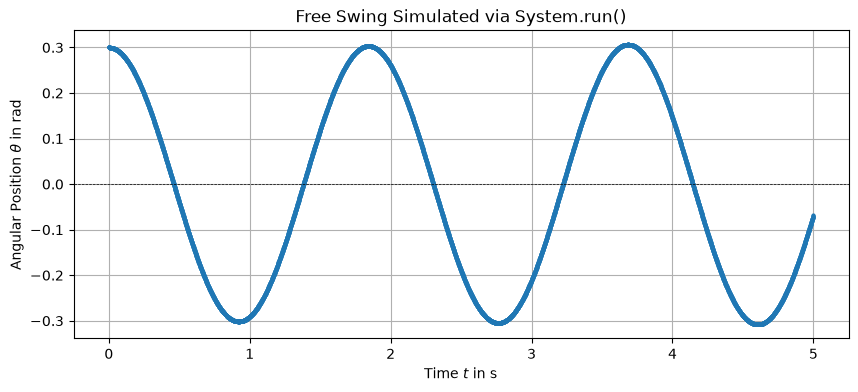

In [20]:
t_vals, data = result["Pendulum"]

plt.figure(figsize=(10, 4))
plt.plot(t_vals, data["theta"], **style)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.title('Free Swing Simulated via System.run()')
plt.xlabel(r'Time $t$ in s')
plt.ylabel(r'Angular Position $\theta$ in rad')
plt.grid()
plt.show()

## Conclusion

In this tutorial, we implemented a minimal pendulum model as a `CoSimComponent` and focused on the three required hooks: `_initialize_component`, `_do_step_internal`, and `_update_output_states`.
We defined input and output ports, set parameters with automatic unit handling, ran a manually stepped simulation with an external torque input, and finally ran the same component inside a `System`, obtaining a `SimulationResult`.

## Next Steps

- {doc}`02_importing_fmus` — replace the hand-written component with a Modelica FMU.
- {doc}`03_first_system` — connect several components into a system with feedback.
- {doc}`/03_core_tutorials/02_intermediate/04_declarative_systems` — assemble the same kind of system from a YAML description instead of Python code.